# Audit CIFAR-100 DNLL (seed1234)

This notebook visualizes per-epoch audit metrics for CIFAR-100 DNLL.
It expects `audit_cifar100_dnll_seed1234.jsonl` in the same folder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "audit_cifar100_dnll_seed1234.jsonl"
df = pd.read_json(path, lines=True)
df.head()


,epoch,split,group,count,g_mean,g_median,g_p90,margin_mean,margin_median,margin_p90,...,s_c_star_p90,p_neg_max_mean,p_neg_max_median,p_neg_max_p90,p_mix_mean,p_mix_median,p_mix_p90,metric,train_acc,test_acc
0,5,train,all,10000.0,0.148589,0.098102,0.318399,-0.279773,-0.270606,2.462157,...,-1.144451,0.148589,0.098102,0.318399,0.665919,0.588189,1.186321,NaN,NaN,NaN
1,5,train,hard5,500.0,0.683396,0.582631,1.019847,-2.614528,-2.302352,-0.483561,...,0.019652,0.683396,0.582631,1.019847,1.157094,1.097622,1.624572,NaN,NaN,NaN
2,5,test,all,10000.0,0.153146,0.101363,0.325067,-0.439543,-0.409576,2.407208,...,-1.123725,0.153146,0.101363,0.325067,0.668129,0.591038,1.204121,NaN,NaN,NaN
3,5,test,hard5,500.0,0.719844,0.621275,1.131538,-2.813405,-2.394118,-0.688891,...,0.123572,0.719844,0.621275,1.131538,1.181379,1.106378,1.715531,NaN,NaN,NaN
4,10,train,all,10000.0,0.135310,0.082114,0.311348,0.598027,0.594594,3.665045,...,-1.166845,0.135310,0.082114,0.311348,0.664437,0.562818,1.210362,NaN,NaN,NaN


In [2]:
df[['epoch', 'split', 'group']].drop_duplicates().sort_values(['epoch', 'split', 'group']).head(12)


,epoch,split,group
2,5,test,all
3,5,test,hard5
0,5,train,all
1,5,train,hard5
6,10,test,all
7,10,test,hard5
4,10,train,all
5,10,train,hard5
10,15,test,all
11,15,test,hard5


In [3]:
def plot_metric_by_group(metric, split):
    subset = df[df['split'] == split]
    pivot = (
        subset
        .pivot_table(index='epoch', columns='group', values=metric)
        .sort_index()
    )
    ax = pivot.plot(marker='o', figsize=(8, 4))
    ax.set_title(f"{metric} by epoch ({split})")
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    return ax


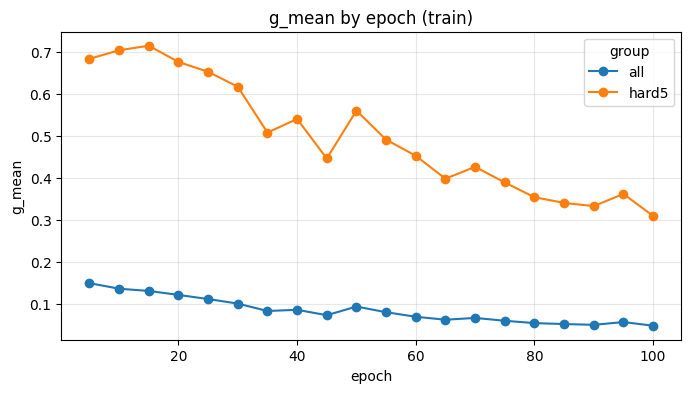

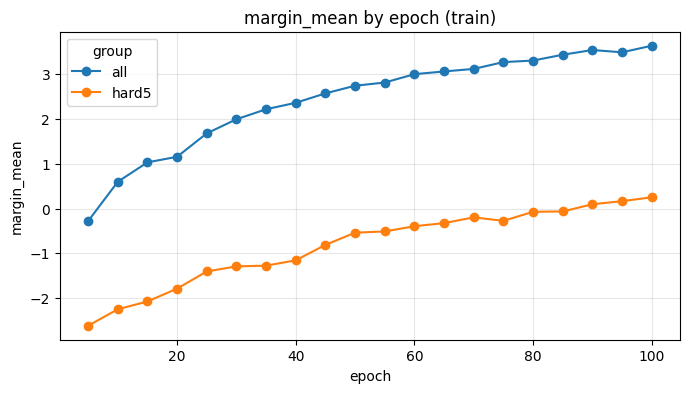

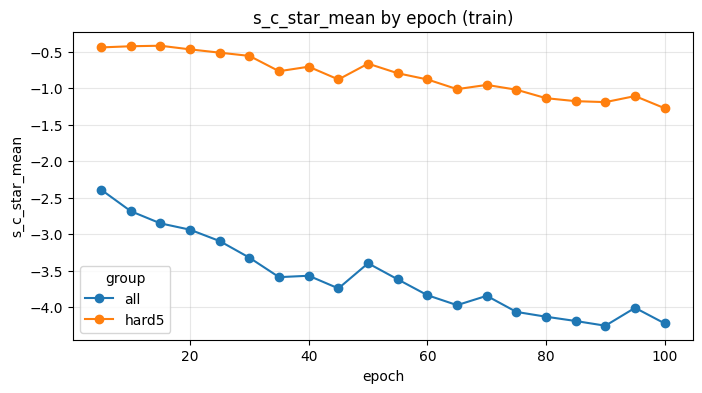

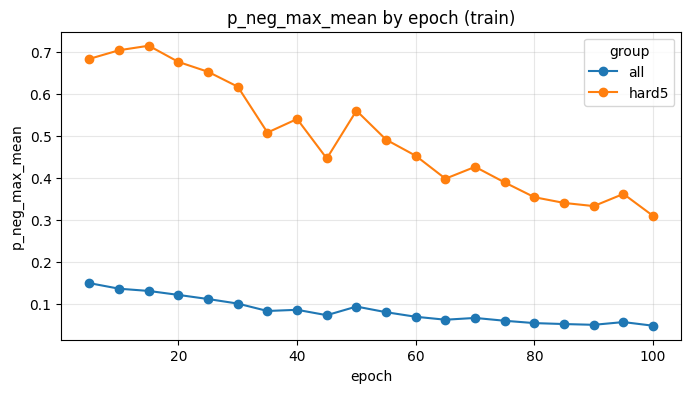

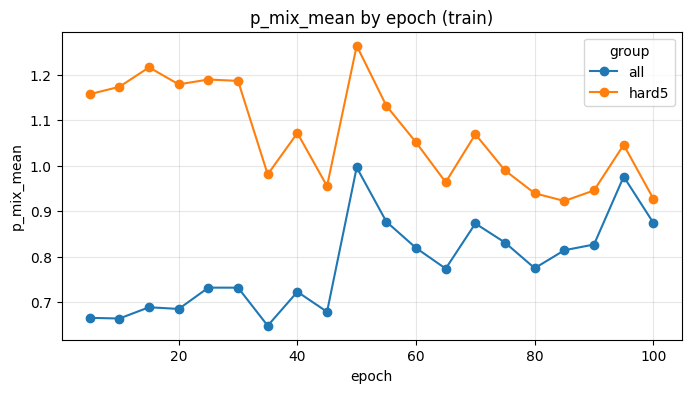

In [4]:
metrics = [
    'g_mean',
    'margin_mean',
    's_c_star_mean',
    'p_neg_max_mean',
    'p_mix_mean',
]

for metric in metrics:
    plot_metric_by_group(metric, split='train')

plt.show()


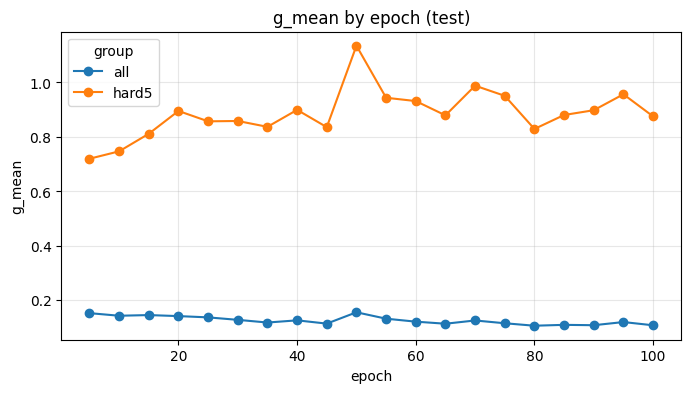

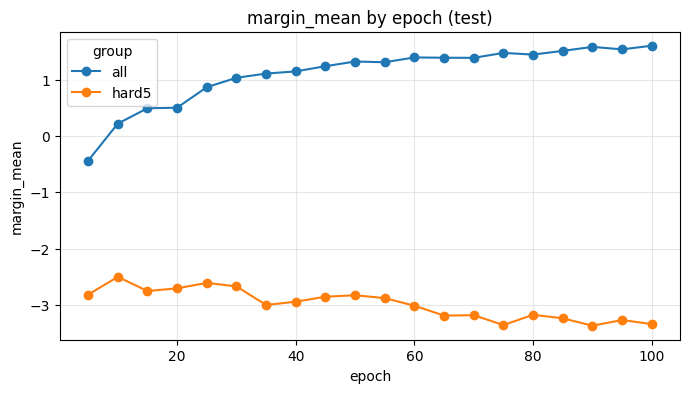

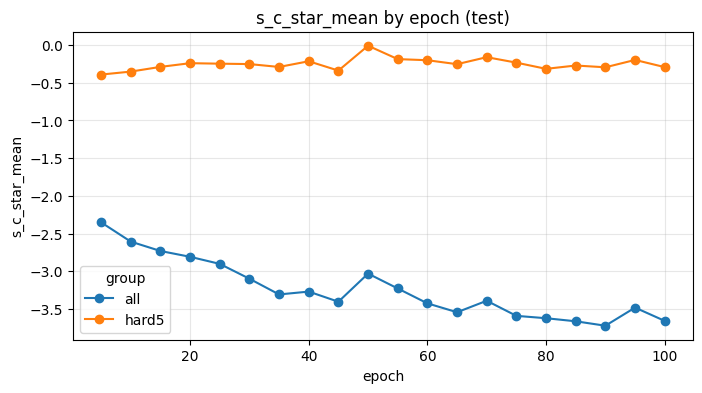

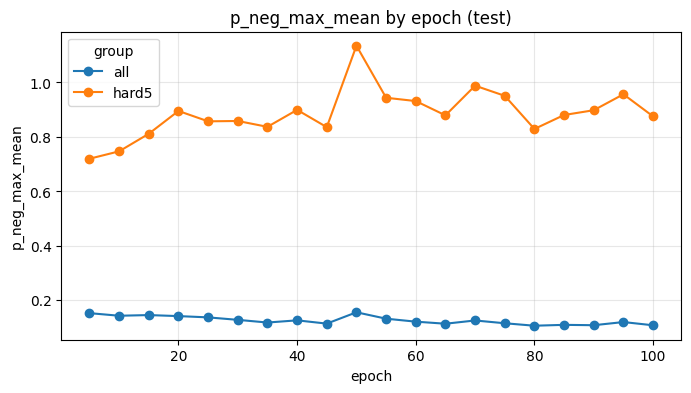

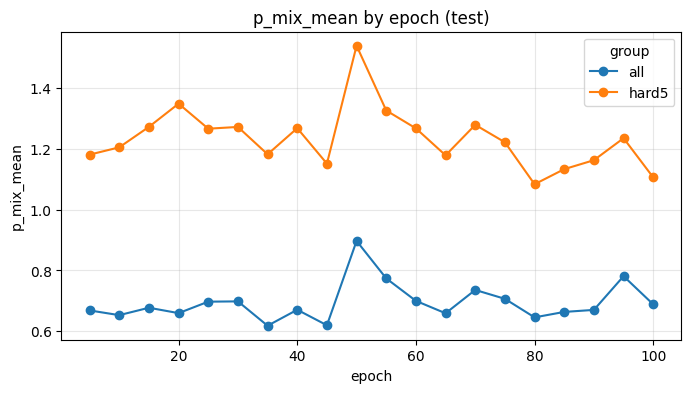

In [5]:
for metric in metrics:
    plot_metric_by_group(metric, split='test')

plt.show()


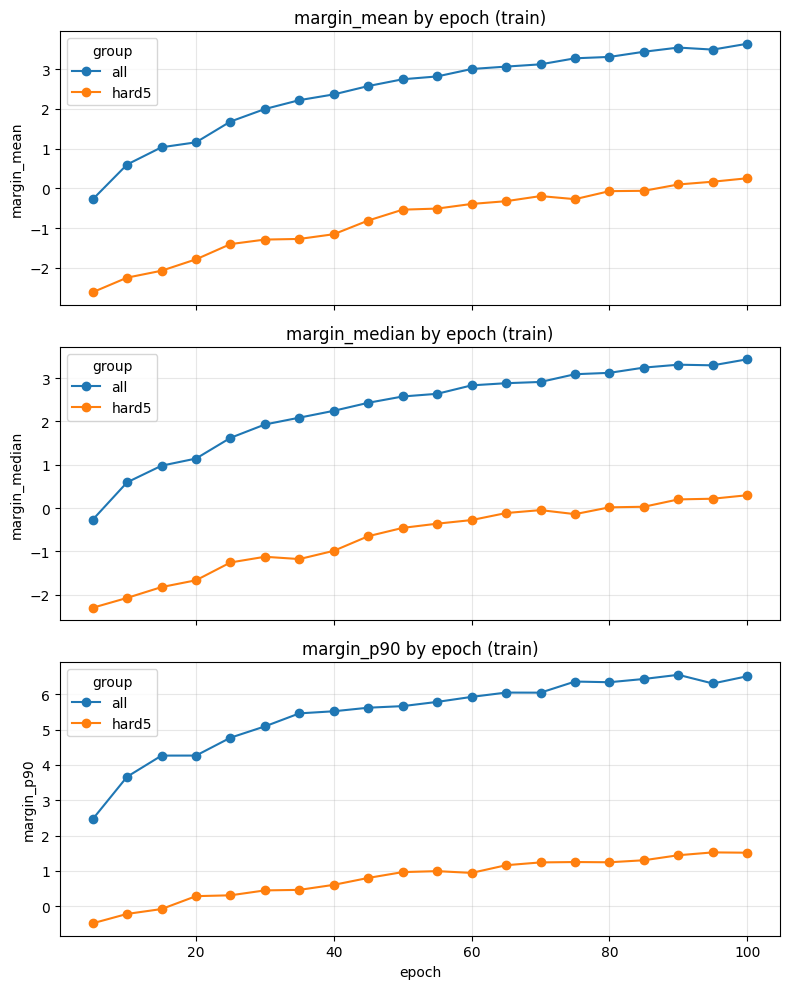

In [6]:
# Compare mean/median/p90 for a chosen metric on one split.
metric = 'margin'
split = 'train'

cols = [f'{metric}_mean', f'{metric}_median', f'{metric}_p90']
subset = df[df['split'] == split]
pivot = subset.pivot_table(index='epoch', columns='group', values=cols)

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 10), sharex=True)
for ax, col in zip(axes, cols):
    pivot[col].sort_index().plot(ax=ax, marker='o')
    ax.set_title(f'{col} by epoch ({split})')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('epoch')
plt.tight_layout()
plt.show()
